## Data Augmentation

### Imports and Functions

In [23]:
import random
import shutil
import cv2
import numpy as np
import xml.etree.ElementTree as ET
from pathlib import Path
from IPython.display import display, Image
from tqdm.notebook import tqdm

# --- Core Transformations ---

def adjust_brightness(image, beta):
    return cv2.convertScaleAbs(image, alpha=1.0, beta=beta)

def adjust_exposure(image, gamma):
    inv_gamma = 1.0 / gamma
    table = np.array([((i / 255.0) ** inv_gamma) * 255 for i in range(256)]).astype("uint8")
    return cv2.LUT(image, table)

def add_gaussian_noise(image, mean=0, sigma=20):
    gauss = np.random.normal(mean, sigma, image.shape).astype('float32')
    noisy_image = np.clip(image.astype('float32') + gauss, 0, 255)
    return noisy_image.astype('uint8')

def rotate_image_and_xml(image, xml_path, angle):
    """
    Rotates image by an angle and recalculates bounding box coordinates in XML.
    """
    h, w = image.shape[:2]
    center = (w / 2.0, h / 2.0)
    M = cv2.getRotationMatrix2D(center, angle, 1.0)
    
    rotated_img = cv2.warpAffine(image, M, (w, h), borderMode=cv2.BORDER_REFLECT)
    
    xml_tree = None
    if xml_path and Path(xml_path).exists():
        xml_tree = ET.parse(str(xml_path))
        root = xml_tree.getroot()
        
        for obj in root.findall('object'):
            bndbox = obj.find('bndbox')
            if bndbox is not None:
                xmin = float(bndbox.find('xmin').text)
                ymin = float(bndbox.find('ymin').text)
                xmax = float(bndbox.find('xmax').text)
                ymax = float(bndbox.find('ymax').text)
                
                corners = np.array([
                    [xmin, ymin],
                    [xmax, ymin],
                    [xmin, ymax],
                    [xmax, ymax]
                ])
                
                ones = np.ones((4, 1))
                points = np.hstack([corners, ones])
                transformed = M.dot(points.T).T
                
                new_xmin = int(np.clip(np.min(transformed[:, 0]), 0, w - 1))
                new_xmax = int(np.clip(np.max(transformed[:, 0]), 0, w - 1))
                new_ymin = int(np.clip(np.min(transformed[:, 1]), 0, h - 1))
                new_ymax = int(np.clip(np.max(transformed[:, 1]), 0, h - 1))
                
                bndbox.find('xmin').text = str(new_xmin)
                bndbox.find('ymin').text = str(new_ymin)
                bndbox.find('xmax').text = str(new_xmax)
                bndbox.find('ymax').text = str(new_ymax)
                
    return rotated_img, xml_tree

# --- Management & Preview ---

def reset_augmented_data(*folder_paths):
    """Recursively deletes specified folders to reset workspace."""
    deleted = False
    for folder in folder_paths:
        path_obj = Path(folder)
        if path_obj.exists():
            shutil.rmtree(path_obj)
            print(f"🗑️ Removed directory tree: {path_obj}")
            deleted = True
    if not deleted:
        print("⚠️ Specified directories do not exist. Nothing cleared.")

def preview_augmentation(
    image_dir, 
    annotation_dir,
    beta_range=(25, 45), 
    gamma_range=(1.3, 1.7), 
    sigma_range=(15, 30),
    angle_range=(-15, 15),
    rotation_prob=0.5
):
    """
    Shows a preview grid demonstrating standalone and combined (Pixel + Rotation) augmentations.
    """
    img_path_obj = Path(image_dir)
    ann_path_obj = Path(annotation_dir)
    valid_exts = ('.jpg', '.jpeg', '.png', '.bmp')
    
    image_paths = [p for p in img_path_obj.rglob('*') if p.suffix.lower() in valid_exts]
    if not image_paths:
        print(f"⚠️ No images found in: {image_dir}")
        return
    
    sample_path = random.choice(image_paths)
    relative_subpath = sample_path.relative_to(img_path_obj)
    xml_path = ann_path_obj / relative_subpath.parent / f"{sample_path.stem}.xml"

    img_bgr = cv2.imread(str(sample_path))
    if img_bgr is None:
        return

    mid_beta = sum(beta_range) // 2
    mid_gamma = sum(gamma_range) / 2.0
    mid_sigma = sum(sigma_range) // 2
    mid_angle = sum(angle_range) / 2.0 or 12.0

    # Individual augmentations
    aug_bright = adjust_brightness(img_bgr, beta=mid_beta)
    aug_noisy = add_gaussian_noise(img_bgr, sigma=mid_sigma)
    
    # Combined augmentation (Bright + Rotated)
    aug_combined, comb_xml = rotate_image_and_xml(aug_bright, xml_path, angle=mid_angle)

    def draw_boxes(img, xml_tree_obj, color=(0, 255, 0)):
        canvas = img.copy()
        if xml_tree_obj is not None:
            root = xml_tree_obj.getroot()
            for obj in root.findall('object'):
                bndbox = obj.find('bndbox')
                if bndbox is not None:
                    xmin = int(float(bndbox.find('xmin').text))
                    ymin = int(float(bndbox.find('ymin').text))
                    xmax = int(float(bndbox.find('xmax').text))
                    ymax = int(float(bndbox.find('ymax').text))
                    cv2.rectangle(canvas, (xmin, ymin), (xmax, ymax), color, 4)
        return canvas

    orig_xml = ET.parse(str(xml_path)) if xml_path.exists() else None

    p_orig = draw_boxes(img_bgr, orig_xml)
    p_bright = draw_boxes(aug_bright, orig_xml)
    p_noisy = draw_boxes(aug_noisy, orig_xml)
    p_comb = draw_boxes(aug_combined, comb_xml, color=(0, 0, 255))

    h, w = p_orig.shape[:2]
    max_dim = 250
    scale = max_dim / max(h, w)
    dim = (int(w * scale), int(h * scale))

    images = [cv2.resize(m, dim) for m in [p_orig, p_bright, p_noisy, p_comb]]
    combined = np.hstack(images)

    labels = ["Original", f"Bright (+{mid_beta})", f"Noise (s={mid_sigma})", f"Bright + Rotated ({mid_angle:.1f}deg)"]
    w_step = dim[0]
    for i, text in enumerate(labels):
        cv2.putText(combined, text, (5 + (i * w_step), 20), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255, 255, 255), 1, cv2.LINE_AA)

    print(f"ℹ️ Configured rotation chance per sample: {rotation_prob * 100:.0f}%")
    _, buffer = cv2.imencode('.jpg', combined)
    display(Image(data=buffer.tobytes()))

# --- Batch Augmentation ---

def augment_dataset(
    image_dir, 
    annotation_dir, 
    output_img_dir, 
    output_xml_dir, 
    sample_ratio=0.3,
    beta_range=(25, 45),
    gamma_range=(1.3, 1.7),
    sigma_range=(15, 30),
    angle_range=(-15, 15),
    rotation_prob=0.5  # Probability (0.0 to 1.0) of applying rotation
):
    """
    Applies a primary pixel transformation and conditionally applies rotation as a secondary step.
    """
    img_path_obj = Path(image_dir)
    ann_path_obj = Path(annotation_dir)
    out_img_obj = Path(output_img_dir)
    out_xml_obj = Path(output_xml_dir)

    valid_extensions = ('.jpg', '.jpeg', '.png', '.bmp')
    image_paths = [p for p in img_path_obj.rglob('*') if p.suffix.lower() in valid_extensions]

    if not image_paths:
        print(f"⚠️ No images found in: {image_dir}")
        return

    num_to_augment = int(len(image_paths) * sample_ratio)
    selected_images = random.sample(image_paths, num_to_augment)
    
    print(f"Augmenting {num_to_augment} images with rotation probability = {rotation_prob * 100:.0f}%...\n")

    pixel_aug_types = ['bright', 'exposed', 'noisy']

    for img_path in tqdm(selected_images, desc="Processing"):
        relative_subpath = img_path.relative_to(img_path_obj)
        category_folder = relative_subpath.parent

        base_name = img_path.stem
        ext = img_path.suffix
        xml_path = ann_path_obj / category_folder / f"{base_name}.xml"

        img = cv2.imread(str(img_path))
        if img is None:
            continue

        # Step 1: Apply Pixel Transformation
        pixel_aug = random.choice(pixel_aug_types)
        
        if pixel_aug == 'bright':
            b_val = random.randint(*beta_range)
            aug_img = adjust_brightness(img, beta=b_val)
        elif pixel_aug == 'exposed':
            g_val = random.uniform(*gamma_range)
            aug_img = adjust_exposure(img, gamma=g_val)
        elif pixel_aug == 'noisy':
            s_val = random.randint(*sigma_range)
            aug_img = add_gaussian_noise(img, sigma=s_val)

        # Step 2: Apply Rotation based on individual probability
        will_rotate = random.random() < rotation_prob
        xml_tree_to_save = None
        aug_tag = pixel_aug

        if will_rotate:
            a_val = random.uniform(*angle_range)
            aug_img, xml_tree_to_save = rotate_image_and_xml(aug_img, xml_path, angle=a_val)
            aug_tag += f"_rotated"

        target_img_dir = out_img_obj / category_folder
        target_xml_dir = out_xml_obj / category_folder
        target_img_dir.mkdir(parents=True, exist_ok=True)
        target_xml_dir.mkdir(parents=True, exist_ok=True)

        new_base_name = f"{base_name}_{aug_tag}"
        new_img_path = target_img_dir / f"{new_base_name}{ext}"
        new_xml_path = target_xml_dir / f"{new_base_name}.xml"

        # Save modified image
        cv2.imwrite(str(new_img_path), aug_img)

        # Save appropriate XML annotation
        if will_rotate and xml_tree_to_save is not None:
            xml_tree_to_save.write(str(new_xml_path))
        elif xml_path.exists():
            shutil.copy(xml_path, new_xml_path)

    print("\n✅ Augmentation complete!")

### Preview Augmentation

ℹ️ Configured rotation chance per sample: 50%


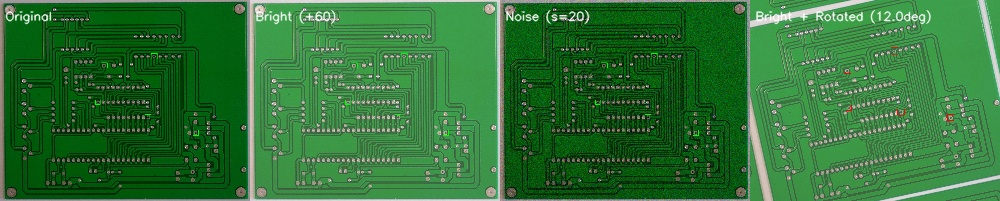

In [25]:
preview_augmentation(
    image_dir='PCB_DATASET/images',
    annotation_dir='PCB_DATASET/annotations',
    beta_range=(50, 70),
    gamma_range=(2.0, 3.0),
    sigma_range=(15, 25),
    angle_range=(-15, 15)  # Tilts image between -15° and +15°
)

### Perform Augmentation

In [27]:
augment_dataset(
    image_dir='PCB_DATASET/images',
    annotation_dir='PCB_DATASET/annotations',
    output_img_dir='PCB_DATASET/augmented_images',
    output_xml_dir='PCB_DATASET/augmented_annotations',
    sample_ratio=0.8,
    beta_range=(50, 70),
    gamma_range=(2.0, 3.0),
    sigma_range=(15, 25), 
    angle_range=(-15, 15)
)

Augmenting 556 images with rotation probability = 50%...



Processing:   0%|          | 0/556 [00:00<?, ?it/s]


✅ Augmentation complete!


### Delete Augmented Images (debug)

In [25]:
reset_augmented_data(
    output_img_dir='PCB_DATASET/augmented_images',
    output_xml_dir='PCB_DATASET/augmented_annotations'
)

⚠️ Directories do not exist. Nothing to clear.


## Preprocessing

### Preprocessing Functions

In [109]:
def preprocess_image(image, to_grayscale=True, blur_ksize=7, blur_sigma=0):
    """
    Converts image to grayscale and applies Gaussian filtering.
    """
    processed = image.copy()
    
    if to_grayscale and len(processed.shape) == 3:
        processed = cv2.cvtColor(processed, cv2.COLOR_BGR2GRAY)
        
    if blur_ksize and blur_ksize > 0:
        if blur_ksize % 2 == 0:
            blur_ksize += 1 # Force odd integer
        processed = cv2.GaussianBlur(processed, (blur_ksize, blur_ksize), blur_sigma)
        
    return processed

def preprocess_dataset(
    image_dir, 
    annotation_dir, 
    output_img_dir, 
    output_xml_dir, 
    to_grayscale=True, 
    blur_ksize=3
):
    """
    Processes 100% of images in a folder (Originals or Augmented) into Grayscale + Blurred.
    """
    img_path_obj = Path(image_dir)
    ann_path_obj = Path(annotation_dir)
    out_img_obj = Path(output_img_dir)
    out_xml_obj = Path(output_xml_dir)

    valid_extensions = ('.jpg', '.jpeg', '.png', '.bmp')
    image_paths = [p for p in img_path_obj.rglob('*') if p.suffix.lower() in valid_extensions]

    if not image_paths:
        print(f"⚠️ No images found in: {image_dir}")
        return

    print(f"Preprocessing {len(image_paths)} images from '{img_path_obj.name}' -> Grayscale={to_grayscale}, Blur={blur_ksize}x{blur_ksize}...")

    for img_path in tqdm(image_paths, desc="Preprocessing Folder"):
        relative_subpath = img_path.relative_to(img_path_obj)
        category_folder = relative_subpath.parent

        base_name = img_path.stem
        ext = img_path.suffix
        xml_path = ann_path_obj / category_folder / f"{base_name}.xml"

        img = cv2.imread(str(img_path))
        if img is None:
            continue

        processed_img = preprocess_image(img, to_grayscale=to_grayscale, blur_ksize=blur_ksize)

        target_img_dir = out_img_obj / category_folder
        target_xml_dir = out_xml_obj / category_folder
        target_img_dir.mkdir(parents=True, exist_ok=True)
        target_xml_dir.mkdir(parents=True, exist_ok=True)

        new_img_path = target_img_dir / f"{base_name}{ext}"
        new_xml_path = target_xml_dir / f"{base_name}.xml"

        cv2.imwrite(str(new_img_path), processed_img)
        if xml_path.exists():
            shutil.copy(xml_path, new_xml_path)

    print(f"✅ Finished preprocessing '{img_path_obj.name}'!\n")

In [105]:
def preview_pipeline(
    image_dir, 
    annotation_dir,
    beta_range=(30, 60), 
    sigma_range=(10, 25),
    angle_range=(-15, 15),
    to_grayscale=True,
    blur_ksize=7
):
    """
    Previews full workflow: Original -> Preprocessed Original -> Augmented -> Preprocessed Augmented
    """
    img_path_obj = Path(image_dir)
    ann_path_obj = Path(annotation_dir)
    valid_exts = ('.jpg', '.jpeg', '.png', '.bmp')
    
    image_paths = [p for p in img_path_obj.rglob('*') if p.suffix.lower() in valid_exts]
    if not image_paths:
        print(f"⚠️ No images found in: {image_dir}")
        return
    
    sample_path = random.choice(image_paths)
    relative_subpath = sample_path.relative_to(img_path_obj)
    xml_path = ann_path_obj / relative_subpath.parent / f"{sample_path.stem}.xml"

    raw_img = cv2.imread(str(sample_path))
    if raw_img is None:
        return

    mid_beta = sum(beta_range) // 2
    mid_sigma = sum(sigma_range) // 2
    mid_angle = sum(angle_range) / 2.0 or 12.0

    # 1. Preprocess Raw
    prep_raw = preprocess_image(raw_img, to_grayscale=to_grayscale, blur_ksize=blur_ksize)

    # 2. Augment Raw
    aug_img = add_gaussian_noise(raw_img, sigma=mid_sigma)
    aug_img, comb_xml = rotate_image_and_xml(aug_img, xml_path, angle=mid_angle)

    # 3. Preprocess Augmented
    prep_aug = preprocess_image(aug_img, to_grayscale=to_grayscale, blur_ksize=blur_ksize)

    def draw_boxes(img, xml_tree_obj, color=(0, 255, 0)):
        canvas = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR) if len(img.shape) == 2 else img.copy()
        if xml_tree_obj is not None:
            root = xml_tree_obj.getroot()
            for obj in root.findall('object'):
                bndbox = obj.find('bndbox')
                if bndbox is not None:
                    xmin = int(float(bndbox.find('xmin').text))
                    ymin = int(float(bndbox.find('ymin').text))
                    xmax = int(float(bndbox.find('xmax').text))
                    ymax = int(float(bndbox.find('ymax').text))
                    cv2.rectangle(canvas, (xmin, ymin), (xmax, ymax), color, 4)
        return canvas

    orig_xml = ET.parse(str(xml_path)) if xml_path.exists() else None

    v_raw = draw_boxes(raw_img, orig_xml)
    v_prep_raw = draw_boxes(prep_raw, orig_xml)
    v_aug = draw_boxes(aug_img, comb_xml, color=(0, 0, 255))
    v_prep_aug = draw_boxes(prep_aug, comb_xml, color=(0, 0, 255))

    h, w = v_raw.shape[:2]
    max_dim = 250
    scale = max_dim / max(h, w)
    dim = (int(w * scale), int(h * scale))

    images = [cv2.resize(m, dim) for m in [v_raw, v_prep_raw, v_aug, v_prep_aug]]
    combined = np.hstack(images)

    labels = ["1. Raw Original", "2. Prep Original", "3. Augmented", "4. Prep Augmented"]
    w_step = dim[0]
    for i, text in enumerate(labels):
        cv2.putText(combined, text, (5 + (i * w_step), 20), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255, 255, 255), 1, cv2.LINE_AA)

    print("ℹ️ Visualization Stage Sequence:")
    _, buffer = cv2.imencode('.jpg', combined)
    display(Image(data=buffer.tobytes()))

### Preview

ℹ️ Visualization Stage Sequence:


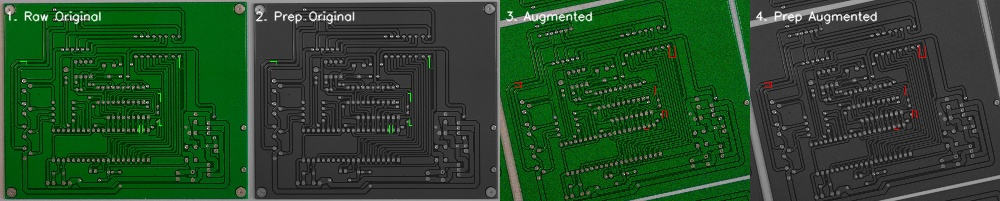

In [103]:
preview_pipeline(
    image_dir='PCB_DATASET/images',
    annotation_dir='PCB_DATASET/annotations',
    to_grayscale=True,
    blur_ksize=11
)

### Preprocess Original & Augmented Data

In [111]:
preprocess_dataset(
    image_dir='PCB_DATASET/images',
    annotation_dir='PCB_DATASET/annotations',
    output_img_dir='PCB_DATASET/processed_originals/images',
    output_xml_dir='PCB_DATASET/processed_originals/annotations',
    to_grayscale=True,
    blur_ksize=11
)

Preprocessing 696 images from 'images' -> Grayscale=True, Blur=11x11...


Preprocessing Folder:   0%|          | 0/696 [00:00<?, ?it/s]

✅ Finished preprocessing 'images'!



In [113]:
preprocess_dataset(
    image_dir='PCB_DATASET/augmented_images',
    annotation_dir='PCB_DATASET/augmented_annotations',
    output_img_dir='PCB_DATASET/processed_augmented/images',
    output_xml_dir='PCB_DATASET/processed_augmented/annotations',
    to_grayscale=True,
    blur_ksize=11
)

Preprocessing 556 images from 'augmented_images' -> Grayscale=True, Blur=11x11...


Preprocessing Folder:   0%|          | 0/556 [00:00<?, ?it/s]

✅ Finished preprocessing 'augmented_images'!

